# 1. Raw data visualization

In [1]:
import numpy as np
import open3d as o3d
import pickle
import matplotlib.pyplot as plt
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from PIL import Image
from IPython.display import display

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Open raw data generated by pybullet and blender

In [2]:
data_path = '../datasets/Objects_2/0'
with open(os.path.join(data_path, 'data.pkl'), "rb") as f: # you can change this directory
    data = pickle.load(f)

### Raw RGB images with virtual RealSense D435 camera generated by Blender

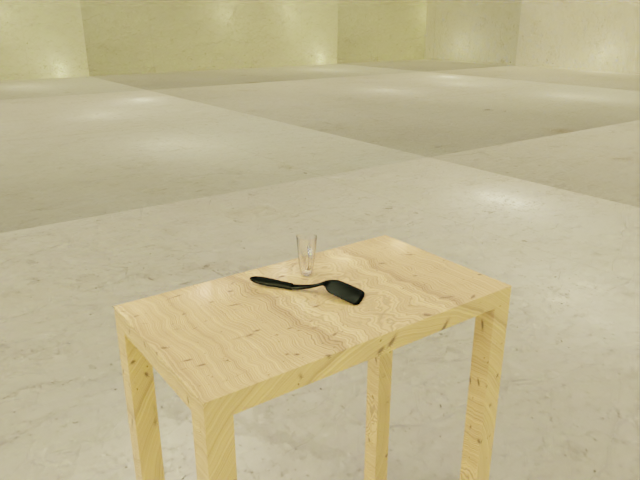

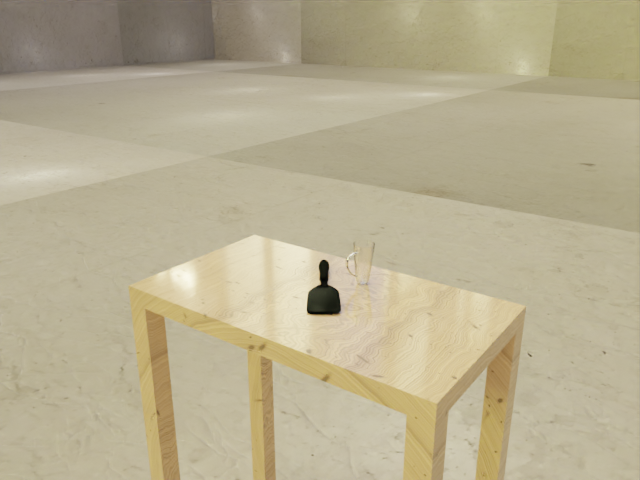

In [3]:
display(Image.fromarray(data['rgb_imgs'][0]))
display(Image.fromarray(data['rgb_imgs'][1]))

### Raw mask images generated by PyBullet

The mask image has shape H×W, where each pixel stores an integer mask ID.  
The background is labeled as -1, and object masks are indexed starting from 0.  
Note that the mask image we ultimately need is an instance mask for the foreground objects, and the labels do not need to be aligned across different views.

C:\Users\82107\AppData\Local\Temp\ipykernel_16316\2175904906.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = plt.cm.get_cmap("tab20", max(n_obj, 1))


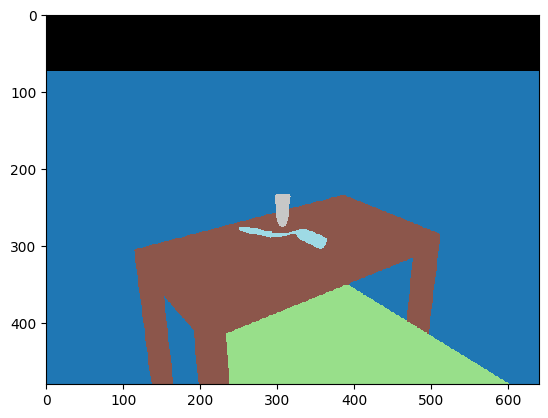

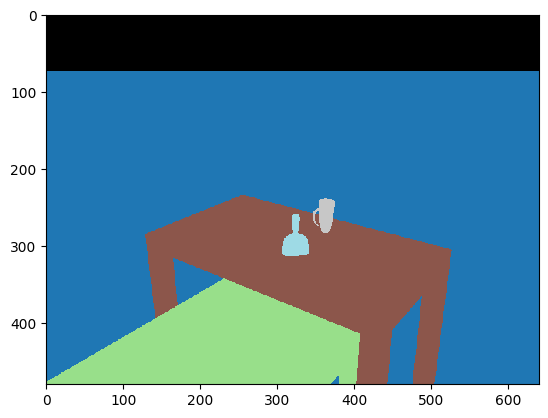

In [4]:
def visualize_instance_mask(mask, figsize=(8, 8), show_colorbar=True):
    obj_ids = np.unique(mask)
    obj_ids = obj_ids[obj_ids >= 0]   # background(-1) 제외
    n_obj = len(obj_ids)

    remapped = np.full_like(mask, fill_value=-1, dtype=np.int32)
    for new_id, old_id in enumerate(obj_ids):
        remapped[mask == old_id] = new_id
    if n_obj <= 20:
        base = plt.cm.get_cmap("tab20", max(n_obj, 1))
    else:
        base = plt.cm.get_cmap("hsv", max(n_obj, 1))

    colors = [(0, 0, 0, 1.0)] + [base(i) for i in range(n_obj)]
    cmap = ListedColormap(colors)

    # background(-1) -> 0, object 0.. -> 1..
    vis = remapped + 1
    norm = BoundaryNorm(np.arange(-0.5, n_obj + 1.5, 1), cmap.N)
    plt.imshow(vis, cmap=cmap, norm=norm, interpolation="nearest")
    plt.show()
visualize_instance_mask(data['mask_imgs'][0])
visualize_instance_mask(data['mask_imgs'][1])


### Ground-truth mesh and camera frames  
The two camera views should be oriented toward the center of the workspace and positioned on the surface of a sphere of equal radius.

In [5]:
# object meshes
meshes = [o3d.io.read_triangle_mesh(os.path.join(data_path, p)) for p in os.listdir(data_path) if p.endswith(".obj")]

# origin frame
origin_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)

# camera frames
cameras = [
    o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1).transform(data['camera'][0]['camera_pose']).translate([-0.61  , 0.0375, -0.3945]),
    o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1).transform(data['camera'][1]['camera_pose']).translate([-0.61  , 0.0375, -0.3945]),
]

# workspace visualization (30cm x 30cm x 30cm)
min_bound = np.array([-0.15, -0.15, -0.15])
max_bound = np.array([ 0.15,  0.15,  0.15])
box = o3d.geometry.AxisAlignedBoundingBox(min_bound, max_bound)
line_box = o3d.geometry.LineSet.create_from_axis_aligned_bounding_box(box)
line_box.paint_uniform_color([1.0, 0.0, 0.0])

o3d.visualization.draw_geometries([origin_frame, line_box] + cameras + meshes)